In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
def load_embeddings(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

topic_embeddings = load_embeddings("../data/embeddings/topic_embeddings.json")

ministry_embeddings = load_embeddings("../data/embeddings/ministry_embeddings1.json")

In [10]:
topics = list(topic_embeddings.keys())
ministries = list(ministry_embeddings.keys())

# -------------------------------
# STEP 1: Build similarity matrix
# -------------------------------
sim_matrix = {}

for t in topics:
    sim_matrix[t] = {}
    for m in ministries:
        score = cosine_similarity(
            [topic_embeddings[t]], 
            [ministry_embeddings[m]]
        )[0][0]
        sim_matrix[t][m] = score

In [11]:
sim_matrix_df = pd.DataFrame(sim_matrix)

In [12]:
sim_matrix_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Ministry_of_Power_MoP_,0.347712,0.055448,0.368150,0.257330,0.120883,0.341969,0.238035,0.050379,0.162871,0.278154,...,0.071502,0.228582,0.215664,0.220208,0.092285,0.072932,0.488943,0.218917,0.183913,0.079293
Ministry_of_Micro_Small_Medium_Enterprises_MoME_,0.360581,0.128394,0.357254,0.247055,0.151847,0.285766,0.348204,0.139568,0.054501,0.300823,...,0.103053,0.240740,0.250911,0.280612,0.180836,0.113487,0.290388,0.279554,0.356951,0.071915
Ministry_of_AYUSH_MoA_,0.105648,0.004689,0.318858,0.151928,0.137090,0.060440,0.080423,-0.051165,-0.046615,0.241910,...,0.017341,0.121212,0.054068,0.185179,0.084044,0.277074,0.057739,0.184138,0.056640,0.509369
Ministry_of_Textiles_MoT_,0.389900,0.113859,0.239779,0.153676,0.080210,0.190852,0.229222,0.196015,0.035890,0.251677,...,0.111634,0.161311,0.243560,0.209540,0.139457,0.159378,0.228013,0.169818,0.512522,0.102721
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_,0.243554,0.060271,0.408641,0.198047,0.193110,0.354145,0.241531,0.080632,0.111517,0.306190,...,0.159678,0.242546,0.241616,0.276801,0.242115,0.104513,0.228575,0.383649,0.140419,0.123309
Ministry_of_Law_and_Justice_MoLJ_,0.113687,0.003942,0.288968,0.216093,0.471863,0.326038,0.170734,-0.024495,0.052342,0.322689,...,0.080049,0.202834,0.318930,0.241248,0.155323,0.009791,0.117374,0.381919,0.098309,0.077477
Ministry_of_Social_Justice_and_Empowerment_MoSJE_,0.140308,0.019615,0.371065,0.215245,0.361564,0.242500,0.119151,0.004070,0.034499,0.346806,...,0.091354,0.231528,0.263225,0.261837,0.337468,0.137626,0.129708,0.266964,0.078000,0.149152
Ministry_of_Culture,0.097560,0.047525,0.314362,0.180844,0.199749,0.172993,0.075859,0.173080,0.012650,0.234976,...,0.033976,0.101390,0.168757,0.275531,0.032746,0.229277,0.015394,0.221852,0.130096,0.092124
Ministry_of_Heavy_Industries_MoHI_,0.488451,0.075941,0.259687,0.185779,0.137716,0.259021,0.189237,0.094987,0.024690,0.257032,...,0.200718,0.241184,0.242779,0.189774,0.138463,0.148418,0.327299,0.224562,0.248053,0.086930
Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,0.383708,0.075244,0.384807,0.202433,0.119751,0.462811,0.285775,0.094276,0.133202,0.249829,...,0.148565,0.177306,0.232484,0.224930,0.134853,0.074027,0.280015,0.313526,0.296042,0.052538


In [13]:

# save the max score
max_sim_score = sim_matrix_df.max(axis=1)

# for each ministry (row), find the topic with highest similarity
sim_matrix_df["Most Similar Topic"] = sim_matrix_df.idxmax(axis=1)

In [14]:
# print topic {id}: and ministries mapped to it
topic_to_ministries = {}
for topic in topics:
    topic_to_ministries[topic] = sim_matrix_df[sim_matrix_df["Most Similar Topic"] == topic].index.tolist()
    
for t in topic_to_ministries:
    print(f"\nTopic {t}:")
    for m in topic_to_ministries[t]:
        score = sim_matrix_df.loc[m, t]
        print("   ", m, f"({score*100:.2f}%)")


Topic 0:
    Ministry_of_Micro_Small_Medium_Enterprises_MoME_ (36.06%)
    Ministry_of_Heavy_Industries_MoHI_ (48.85%)

Topic 1:
    Ministry_of_Information_and_Broadcasting_MIB_ (43.31%)

Topic 2:
    Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_ (40.86%)
    Ministry_of_Social_Justice_and_Empowerment_MoSJE_ (37.11%)
    Ministry_of_Culture (31.44%)
    Ministry_of_Tourism_MoT_ (28.29%)
    Ministry_of_Environment_Forest_and_Climate_Change_MoEFCC_ (34.95%)
    Ministry_of_Health_and_Family_Welfare_MoHFW_ (41.64%)
    Ministry_of_Development_of_North_Eastern_Region_MDoNER_ (37.36%)
    Ministry_of_Science_and_Technology_MST_ (38.05%)
    Ministry_of_Finance_MoF_ (38.93%)

Topic 3:

Topic 4:
    Ministry_of_Law_and_Justice_MoLJ_ (47.19%)
    Ministry_of_Minority_Affairs_MoMA_ (42.15%)

Topic 5:
    Ministry_of_Statistics_and_Programme_Implementation_MoSPI_ (46.28%)
    Ministry_of_Planning_MoP_ (46.26%)
    Ministry_of_Communications_MoC_ (41.51%)
    Ministry_of_Parliam

In [15]:
# using max_sim_score, and sim_matrix_df["Most Similar Topic"], build a dataframe with columns: "Topic", "Most Similar Ministry", "Similarity Score"
topic_ministry_df = pd.DataFrame({
    "TopicID": sim_matrix_df["Most Similar Topic"],
    "Score": max_sim_score
})
topic_ministry_df      

,TopicID,Score
Ministry_of_Power_MoP_,21,0.488943
Ministry_of_Micro_Small_Medium_Enterprises_MoME_,0,0.360581
Ministry_of_AYUSH_MoA_,24,0.509369
Ministry_of_Textiles_MoT_,23,0.512522
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_,2,0.408641
Ministry_of_Law_and_Justice_MoLJ_,4,0.471863
Ministry_of_Social_Justice_and_Empowerment_MoSJE_,2,0.371065
Ministry_of_Culture,2,0.314362
Ministry_of_Heavy_Industries_MoHI_,0,0.488451
Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,5,0.462811


In [16]:
# reset index to get ministry as a column
topic_ministry_df = topic_ministry_df.reset_index().rename(columns={"index": "Ministry"})
topic_ministry_df[['TopicID', 'Ministry', 'Score']].to_csv("../data/topic_modeling/topic_ministry_mapping1.csv", index=False)

In [17]:
# print if any ministry is mapped to multiple topics
ministry_count = {}
for ministry in ministries:
    ministry_count[ministry] = sim_matrix_df[sim_matrix_df["Most Similar Topic"] == ministry].shape[0]
    
for ministry, count in ministry_count.items():
    if count > 1:
        print(f"{ministry} is mapped to {count} topics")

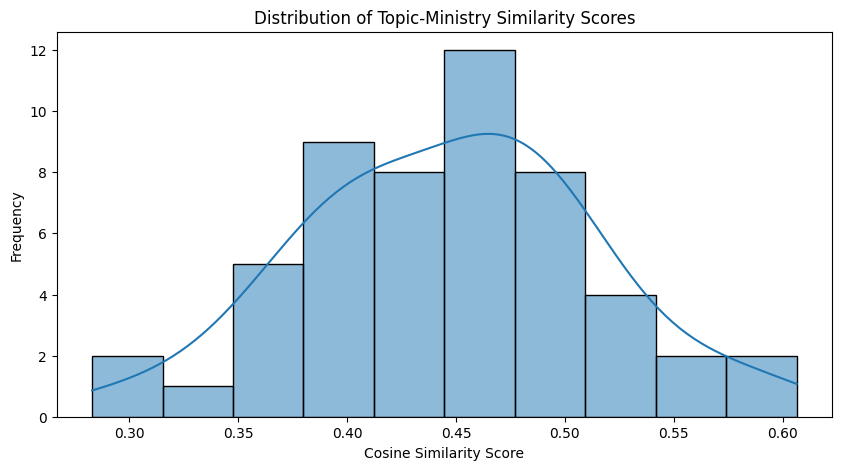

In [18]:
# plot score wise frequency distribution
plt.figure(figsize=(10,5))
sns.histplot(topic_ministry_df['Score'].values, bins=10, kde=True)
plt.title("Distribution of Topic-Ministry Similarity Scores")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.show()